# Assignment 5
### Do all four questions.
#### Jarrett Markman

**1.** Let's review some basic matrix multiplication. When you have an $M \times N$ matrix $A$ with $M$ rows and $N$ columns, 
$$
A= \left[ \begin{array}{cccc} a_{11} & a_{12} & ... & a_{1N} \\
a_{21} & a_{22} & ... & a_{2N} \\
\vdots & \vdots & ... & \vdots \\
a_{M1} & a_{M2} & ... & a_{MN} 
\end{array} \right],
$$
and you right-multiply it by a vector
$$
x = \left[ \begin{array}{c} x_1 \\ x_2 \\ \vdots \\ x_N 
\end{array} \right],
$$
you get
$$
Ax = \left[ \begin{array}{c} \sum_{i=1}^N a_{1i} x_i \\ \sum_{i=1}^N a_{2i} x_i \\ \vdots \\ \sum_{i=1}^N a_{Mi} x_i 
\end{array} \right].
$$
This is just "matrix row times column vector" element-by-element, stacking the results into a new vector.

For this to make sense, $N$ must be the same for the matrix and the vector, but $M$ can be different from $N$. 

Let's play with some NumPy to see this. First we'll define a matrix $A$:

In [2]:
import numpy as np

A = np.array([ [1,2,3],
              [4,5,6],
              [7,8,9]])
A

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

a. Multiply $A$ times each of the following vectors using the @ operator. Explain which part of the $A$ matrix gets selected and explain why, using the definition of matrix multiplication. 

In [74]:
e_1 = np.array([1,0,0])
e_2 = np.array([0,1,0])
e_3 = np.array([0,0,1])

In [22]:
print(A @ e_1, A @ e_2, A @ e_3, sep='\n')

[1 4 7]
[2 5 8]
[3 6 9]


A is a 3-by-3 matrix while each e is one-dimensional array with three elements, meaning the matrix multiplication of A by each e will become another one-dimensional array with 3 elements. Based on the structure for each e, each of the multiplied arrays will contain the columns for matrix A, as each of the other elements will be multiplied by 0. 

For example, the matrix multiplication for A@e_3 is:

$$1(0) + 2(0) + 3(1) = 3$$
$$4(0) + 5(0) + 6(1) = 6$$
$$7(0) + 8(0) + 9(1) = 9$$

Which leaves a single-dimension array with the elements $[3, 6, 9]$.

b. Now multiply $A$ times $u = (1,1,1)$. Explain the logic of the result with the definition of matrix multiplication.

In [31]:
u = np.ones(3)
print(u, A@u, sep='\n')

[1. 1. 1.]
[ 6. 15. 24.]


In contrast to the matrix multiplication above, instead of multiplying A with a one-dimensional array with 3 elements where 2 values are 0 and 1 value is 1, the 3 elements in the array are 1's, which leaves you with this type of equation:
$$1(1) + 2(1) + 3(1) = 6$$
$$4(1) + 5(1) + 6(1) = 15$$
$$7(1) + 8(1) + 9(1) = 24$$

Which leaves you with another single-dimension array with the elements $[6, 15, 24]$

c. Whenever a matrix has 1's on the diagonal and zeros everywhere else, we call it an **identity matrix**. What happens when you multiple $A$ times $x$ below? What happens when you multiple an identity matrix times any vector? Explain your result with the definition of matrix multiplication.

In [9]:
A = np.array([ [1,0,0],
              [0,1,0],
              [0,0,1]])
x = np.array([-2,4,11])
A@x

array([-2,  4, 11])

If you multiply the identidy matrix with any vector, you will just return the vector itself. 

For example, in this case you return the same array of x with the matrix multiplication as:

$$-2(1) + 4(0) + 11(0) = -2$$
$$-2(0) + 4(1) + 11(0) = 4$$
$$-2(0) + 4(0) + 11(1) = 11$$

So you just return the same array: $[-2, 4, 11]$

d. What if every row and column sum to 1, but the 1's are no longer on the diagonal? Multiple $A$ times $X$ below and explain the result. Create another matrix whose rows and columns sum to 1, but is not an identity matrix, and show how it permutes the values of $x$. 

In [10]:
A = np.array([ [0,0,1],
              [1,0,0],
              [0,1,0]])
x = np.array([-2,4,11])
A@x

array([11, -2,  4])

A is now a different matrix, so instead of listing the array in the way it came, based on the matrix structure of A, it's selecting the third, then first, then second elements from x here. Mathematically as:

$$-2(0) + 4(0) + 11(1) = 11$$
$$-2(1) + 4(0) + 11(0) = -2$$
$$-2(0) + 4(1) + 11(0) = 4$$

Which leaves you with the array: $[11, -2, 4]$. 

In [ ]:
# Can also do (inverse of identity matrix):
A = np.array([ [0,0,1],
              [0,1,0],
              [1, 0,0]])
x = np.array([-2,4,11])
A@x

array([11,  4, -2])

## Explain

e. The next matrix $A$ could be a Markov transition matrix: Its columns sum to 1, and each entry $a_{ij}$ can be interpreted as the proportion of observations who moved from state $j$ to state $i$. Multiply $A$ by each of the vectors $e_1$, $e_2$, and $e_3$, and explain your results.

In [40]:
rng = np.random.default_rng(100)
A = rng.random((3,3)) # Generate a random 3X3 matrix
sums = np.sum(A,axis=0) # Column sums
A = A/sums # Normalize the columns so they sum to 1
print(A)

[[0.50052958 0.24049286 0.18358131]
 [0.02574731 0.39251588 0.37907577]
 [0.47372311 0.36699127 0.43734292]]


In [37]:
A.shape

(3, 3)

In [36]:
print(A@e_1, A@e_2, A@e_3, sep='\n')

[0.50052958 0.02574731 0.47372311]
[0.24049286 0.39251588 0.36699127]
[0.18358131 0.37907577 0.43734292]


A is a 3x3 matrix, and is individually being multiplied by each of the one-dimensional e vectors with three elements created in part a. The 3 arrays display the values for each of the 3 columns in A for the 3 different e vectors. 

Here the matrix multiplication of something like A@e_1 (a one-dimensional array $[1, 0, 0]$) is:

$$0.50052958(1) + 0.24049286(0) + 0.18358131(0) = 0.50052958$$
$$0.02574731(1) + 0.39251588(0) + 0.37907577(0) = 0.02574731$$
$$0.47372311(1) + 0.36699127(0) + 0.43734292(0) = 0.47372311$$
Which leaves the array of $[0.50052958, 0.02574731, 0.47372311]$

f. For each of the vectors $e_1, e_2, e_3$, multiple $A$ times that vector 5 times. What answer do you get for each starting vector? Describe the behavior you observe.

In [83]:
def starting_vectors(vec):
    for i in range(5):
        vec = A @ vec
        print(f"Multiplication {i+1}: {vec}")

In [84]:
starting_vectors(e_1)

Multiplication 1: [0.50052958 0.02574731 0.47372311]
Multiplication 2: [0.34368862 0.20257047 0.45374091]
Multiplication 3: [0.30404142 0.26036337 0.43559521]
Multiplication 4: [0.29476439 0.27514859 0.43008701]
Multiplication 5: [0.29266551 0.27862515 0.42870935]


In [85]:
starting_vectors(e_2)

Multiplication 1: [0.24049286 0.39251588 0.36699127]
Multiplication 2: [0.28214379 0.29937825 0.41847795]
Multiplication 3: [0.29004438 0.28341002 0.42654561]
Multiplication 4: [0.29163968 0.2804039  0.42795643]
Multiplication 5: [0.29197422 0.27979983 0.42822595]


In [86]:
starting_vectors(e_3)

Multiplication 1: [0.18358131 0.37907577 0.43734292]
Multiplication 2: [0.26334088 0.31930609 0.41735304]
Multiplication 3: [0.28521895 0.29032145 0.4244596 ]
Multiplication 4: [0.29050361 0.28220175 0.42729464]
Multiplication 5: [0.29171646 0.2802254  0.42805814]


The final starting vectors are as follows:
- $[0.29206603, 0.27963849, 0.42829548]$
- $[0.29197422, 0.27979983, 0.42822595]$
- $[0.29171646, 0.2802254,  0.42805814]$

It's interesting to note the progression for each of the vectors after 5 multiplications, to see how each vector progressed to similar starting values of roughly $[0.29, 0.28, 0.43]$. The vectors are very similar for each e. These values are indicative of the distribution for these vectors over a larger sample (for example, if there were maybe 10 multiplications, the results wouldn't change much if at all). 

*2.* Let's consider a simple Markov transition matrix over two states:
$$
T = \left[ \begin{array}{cc} p_{1\leftarrow 1} &  p_{1\leftarrow 2} \\
p_{2 \leftarrow 1} & p_{2 \leftarrow 2} \end{array}\right] 
$$
The arrows help visualize the transition a bit: This is the same index notation as usual, $p_{ij}$, but writing it $p_{i \leftarrow j}$ emphasizes that it's the proportion of times that state $j$ transitions to state $i$. Below, $T$ is given by
$$
T = \left[ \begin{array}{cc} .25 & .5 \\
.75 & .5 \end{array}\right].
$$

- Start in state 1, at the initial condition $[1,0]$. Multiply that vector by $T$. Write out the result in terms of the formula and compute the result in a code chunk below. What is this object you're looking at, in terms of proportions and transitions?
- Multiple by $T$ again. What do you get? This isn't a column of $T$. Explain in words what it is. (Hint: A forecast of what in what period?)
- Keep multiplying the current vector of outcomes by $T$. When does it start to settle down without changing further?
- Do the above analysis again, starting from the initial condition $[0,1]$. Do you get a different result?
- The take-away is that, in the long run, these chains settle down into the long-run proportions, and the sensitivity on initial conditions vanishes. 


In [88]:
T = np.array([[ 1/4, 1/2],
                 [ 3/4, 1/2 ]])

In [89]:
state = np.array([1,0])
T @ state

array([0.25, 0.75])

This vector is just representative of the first column of T which represents the transition probabilities from state 1 to either state 1 or state 2. 

The multiplication here is:

$$0.25(1) + 0.5(0) = 0.25$$
$$0.75(1) + 0.5(0) = 0.75$$

Which yields the array $[0.25, 0.75]$

This means there is a probability of $0.25$ and $0.75$ to be in state 1 or state 2 (respectively) coming from state 1. 

In [92]:
state1 = T@state
T@state1

array([0.4375, 0.5625])

The multiplication being performed here is:

$$0.25(0.25) + 0.75(0.5) = 0.4375$$
$$0.25(0.75) + 0.25(0.5) = 0.5625$$

This is representative of a forecast in the second period. Specifically it's the likelihood of being in either state 1 or state 2 in the second period given that you start in state 1. 

In [ ]:
# Iterate through 15 forecasts
for i in range(15):
    state = T @ state
    print(f"{i+1}: {state}") 

1: [0.25 0.75]
2: [0.4375 0.5625]
3: [0.390625 0.609375]
4: [0.40234375 0.59765625]
5: [0.39941406 0.60058594]
6: [0.40014648 0.59985352]
7: [0.39996338 0.60003662]
8: [0.40000916 0.59999084]
9: [0.39999771 0.60000229]
10: [0.40000057 0.59999943]
11: [0.39999986 0.60000014]
12: [0.40000004 0.59999996]
13: [0.39999999 0.60000001]
14: [0.4 0.6]
15: [0.4 0.6]


The values start to settle down by the 3th forecast, where they iterate between values just above and below 0.4 and 0.6. Ultimately at the 14th iteration, the values appear to converge to 0.4 and 0.6. 

In [94]:
# Forecast for a different starting state
state = np.array([0, 1])
for i in range(15):
    state = T @ state
    print(f"{i+1}: {state}") 

1: [0.5 0.5]
2: [0.375 0.625]
3: [0.40625 0.59375]
4: [0.3984375 0.6015625]
5: [0.40039062 0.59960938]
6: [0.39990234 0.60009766]
7: [0.40002441 0.59997559]
8: [0.3999939 0.6000061]
9: [0.40000153 0.59999847]
10: [0.39999962 0.60000038]
11: [0.4000001 0.5999999]
12: [0.39999998 0.60000002]
13: [0.40000001 0.59999999]
14: [0.4 0.6]
15: [0.4 0.6]


The early forecasts (when starting from state 2) differ, however as you iterate further, the values converge to 0.4 and 0.6 just like when starting at state 1. Like with the previous code block, the values start to stabilize around the 3rd iteration/forecast.

3. Weather data

- Load the `cville_weather.csv` data. This includes data from Jan 4, 2024 to Feb 2, 2025. Are there any missing data issues?
- Based on the precipitation variable, `PRCP`, make a new variable called `rain` that takes the value 1 if `PRCP`>0 and 0 otherwise.
- Build a two-state Markov chain over the states 0 and 1 for the `rain` variable. 
- For your chain from c, how likely is it to rain if it was rainy yesterday? How likely is it to rain if it was clear yesterday?
- Starting from a clear day, forecast the distribution. How quickly does it converge to a fixed result? What if you start from a rainy day?
- Conditional on being rainy, plot a KDE of the `PRCP` variable.
- Describe one way of making your model better for forecasting and simulation the weather.

Congratulations, you now are a non-parametric meteorologist!

In [95]:
import pandas as pd
weather = pd.read_csv("cville_weather.csv")

In [96]:
weather.isna().sum()

STATION              0
NAME                 0
DATE                 0
DAPR               399
DAPR_ATTRIBUTES    399
MDPR               399
MDPR_ATTRIBUTES    399
PRCP                12
PRCP_ATTRIBUTES     12
SNOW               188
SNOW_ATTRIBUTES    188
SNWD               410
SNWD_ATTRIBUTES    410
dtype: int64

In [59]:
weather.head()

,STATION,NAME,DATE,DAPR,DAPR_ATTRIBUTES,MDPR,MDPR_ATTRIBUTES,PRCP,PRCP_ATTRIBUTES,SNOW,SNOW_ATTRIBUTES,SNWD,SNWD_ATTRIBUTES
0,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-04,NaN,NaN,NaN,NaN,0.03,",,N",NaN,NaN,NaN,NaN
1,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-07,NaN,NaN,NaN,NaN,1.08,",,N",NaN,NaN,NaN,NaN
2,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-09,NaN,NaN,NaN,NaN,0.24,",,N",NaN,NaN,NaN,NaN
3,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-10,NaN,NaN,NaN,NaN,3.00,",,N",NaN,NaN,NaN,NaN
4,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-24,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN


Yes there is a lot of missing data present within this weather dataset, we can identify this by looking at the data frame itself as well as looking at the counts for NA values. 

In [98]:
# Build rain variable based on PRCP > 0
weather['rain'] = [1 if prcp > 0 else 0 for prcp in weather['PRCP']]
weather['rain']

0      1
1      1
2      1
3      1
4      0
      ..
406    0
407    0
408    0
409    0
410    0
Name: rain, Length: 411, dtype: int64

In [111]:
mc = pd.crosstab(weather["rain"].shift(1), weather["rain"], normalize='index', rownames=["From Rain..."], colnames=["...To Rain"])
print("Markov Chain for Rain: \n")
mc

Markov Chain for Rain: 



...To Rain,0,1
From Rain...,,
0.0,0.731602,0.268398
1.0,0.351955,0.648045


In [108]:
# rain given rainy
rr = mc[1][1]
# rain given clear
rc = mc[1][0]
print(f"Probability of Rain given Rain: {rr}")
print(f"Probability of Rain given Clear: {rc}")

Probability of Rain given Rain: 0.6480446927374302
Probability of Rain given Clear: 0.2683982683982684


In [117]:
state = np.array([1, 0]) # clear forecast
T = mc.values.T
for i in range(15):
    state = T @ state
    print(f"Day {i+1}: Clear: {state[0]:.4f}, Rainy: {state[1]:.4f}")

Day 1: Clear: 0.7316, Rainy: 0.2684
Day 2: Clear: 0.6297, Rainy: 0.3703
Day 3: Clear: 0.5910, Rainy: 0.4090
Day 4: Clear: 0.5763, Rainy: 0.4237
Day 5: Clear: 0.5708, Rainy: 0.4292
Day 6: Clear: 0.5686, Rainy: 0.4314
Day 7: Clear: 0.5678, Rainy: 0.4322
Day 8: Clear: 0.5675, Rainy: 0.4325
Day 9: Clear: 0.5674, Rainy: 0.4326
Day 10: Clear: 0.5674, Rainy: 0.4326
Day 11: Clear: 0.5674, Rainy: 0.4326
Day 12: Clear: 0.5674, Rainy: 0.4326
Day 13: Clear: 0.5673, Rainy: 0.4327
Day 14: Clear: 0.5673, Rainy: 0.4327
Day 15: Clear: 0.5673, Rainy: 0.4327


In [118]:
state = np.array([0, 1]) # rain forecast
T = mc.values.T
for i in range(15):
    state = T @ state
    print(f"Day {i+1}: Clear: {state[0]:.4f}, Rain: {state[1]:.4f}")

Day 1: Clear: 0.3520, Rain: 0.6480
Day 2: Clear: 0.4856, Rain: 0.5144
Day 3: Clear: 0.5363, Rain: 0.4637
Day 4: Clear: 0.5556, Rain: 0.4444
Day 5: Clear: 0.5629, Rain: 0.4371
Day 6: Clear: 0.5656, Rain: 0.4344
Day 7: Clear: 0.5667, Rain: 0.4333
Day 8: Clear: 0.5671, Rain: 0.4329
Day 9: Clear: 0.5673, Rain: 0.4327
Day 10: Clear: 0.5673, Rain: 0.4327
Day 11: Clear: 0.5673, Rain: 0.4327
Day 12: Clear: 0.5673, Rain: 0.4327
Day 13: Clear: 0.5673, Rain: 0.4327
Day 14: Clear: 0.5673, Rain: 0.4327
Day 15: Clear: 0.5673, Rain: 0.4327


The start for each of the forecast's given a clear or rainy day is drastically different, however, after a few days it begins to converge at ~$57\%$ clear, $43\%$ rainy, which can be seen around the 5th day when starting with a clear day and around the 6th day when starting with a rainy day. The values converge to $0.5673$ clear, $0.4327$ rainy. 

<Axes: xlabel='PRCP', ylabel='Density'>

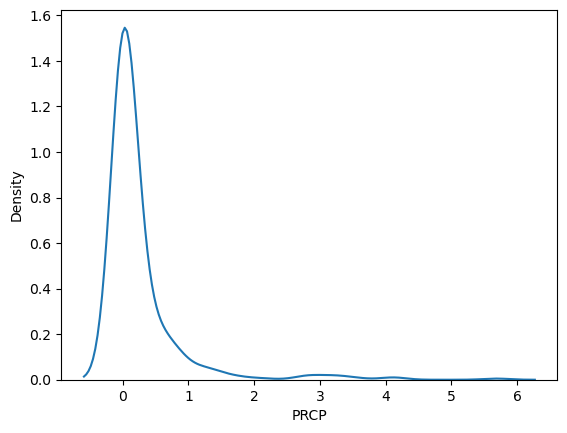

In [119]:
# KDE for PRCP
import seaborn as sns
sns.kdeplot(data=weather['PRCP'], label='PRCP')

Weather isn't as binary as clear or rainy. There are a lot of potential other weather conditions (or states) that can be included in this model, such as cloudy, overcast, or snowy. Not to mention that there are different levels of precipitation, which can potentially be predictive of further precipitation or not. 

4. Taxicab trajectories: Using the pickled taxicab data, we want to complete the exercise from class.

- For the taxicab trajectory data, determine your state space and clean your sequences of cab rides.
- Compute the transition matrix for the taxicab data between neighborhoods in Manhattan. Plot it in a heat map. What are the most common routes?
- Explain why taxicabs are most likely order 1, and not 2 or more.
- Starting at Hell's Kitchen, create a sequence of forecasts of where the cab is likely to be in 2, 3, 5, and 10 trips
- Starting at any neighborhood, iterate your forecast until it is no longer changing very much. Where do cabs spend most of their time working in Manhattan?

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import pickle

In [4]:
with open('taxicab.pkl', 'rb') as f:
    data = pickle.load(f)

In [120]:
states = set(data[0])

for i in range(1, len(data)):
    new_trip = data[i]
    new_states = set(new_trip)
    states = states.union(new_states)

states = list(states)
print("State Space for Taxi Trips: ", states)

State Space for Taxi Trips:  ['Stuyvesant Town', "Randall's Island", 'Battery Park City', 'Outside Manhattan', 'Chinatown', 'Washington Heights', 'Midtown', 'Murray Hill', 'Upper East Side', 'Governors Island', 'Greenwich Village', 'Morningside Heights', 'Tribeca', 'Chelsea', 'Nolita', 'Inwood', 'Roosevelt Island', 'Central Park', 'Gramercy', 'Liberty Island', 'Theater District', 'East Village', 'West Village', 'Financial District', 'East Harlem', 'Little Italy', 'Marble Hill', 'Kips Bay', 'Ellis Island', 'NoHo', 'Civic Center', 'Two Bridges', 'SoHo', 'Flatiron District', 'Harlem', 'Lower East Side', 'Upper West Side', "Hell's Kitchen"]


In [121]:
tr_counts = np.zeros( (len(states), len(states)) )

for trip in data:
    seq = np.array(trip)
    for t in range(1, len(seq)):
        x_tm1 = seq[t-1]
        x_t = seq[t]
        index_from = states.index(x_tm1)
        index_to = states.index(x_t)
        tr_counts[index_to, index_from] += 1

In [122]:
sums = tr_counts.sum(axis=0, keepdims = True)

In [123]:
tr_pr = np.divide(tr_counts, sums, 
                  out = np.zeros_like(tr_counts),
                  where=sums!=0)    
tr_df = pd.DataFrame(np.round(tr_pr, 2), index = states, columns = states)

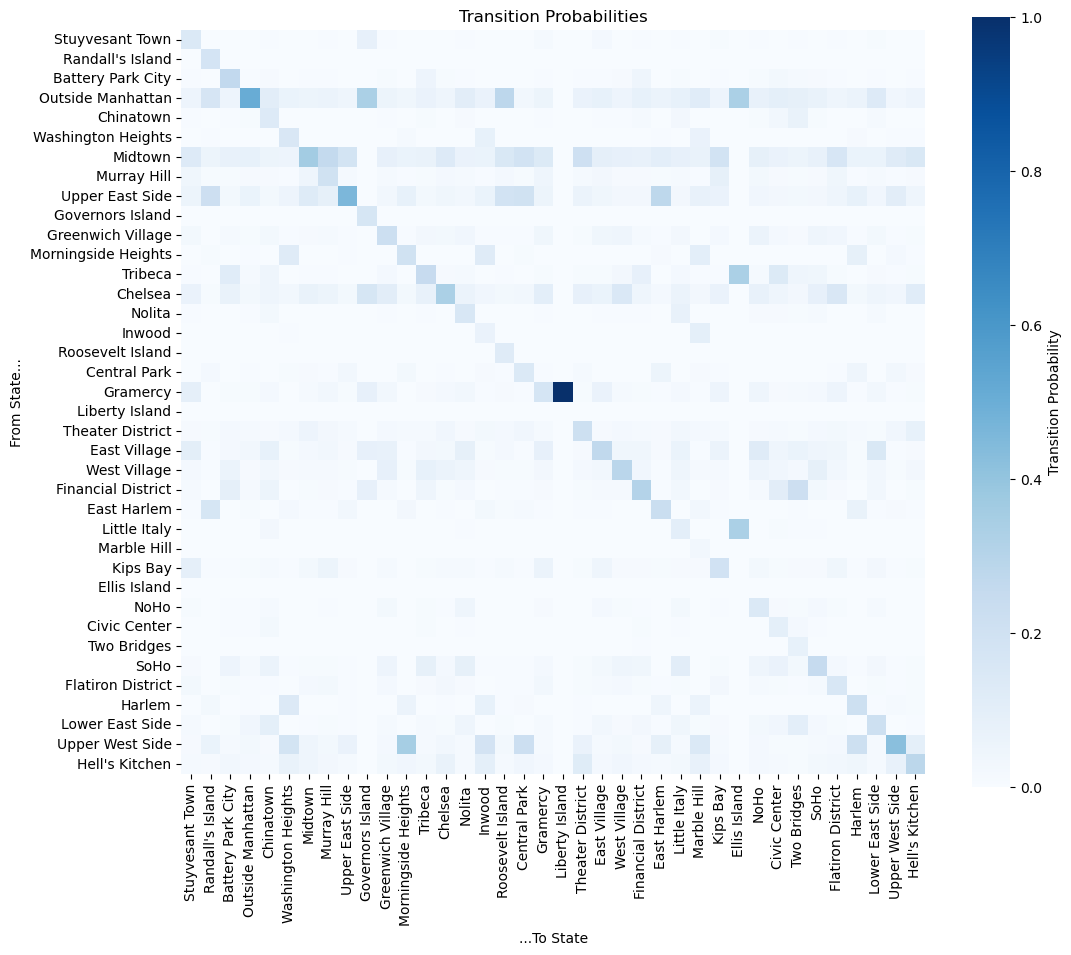

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,10))
sns.heatmap(tr_pr, 
            cmap = 'Blues',
            square = True,
            xticklabels = states,
            yticklabels=states,
            cbar_kws={'label': 'Transition Probability'})
plt.title("Transition Probabilities")
plt.xlabel('...To State')
plt.ylabel('From State...')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

We can identify some of the more frequent trips based upon the darkness of the squares present in the visual above. Notable frequent trips are Gramercy to Liberty Island, Outside Manhattan to Outside Manhattan, Tribeca to Ellis Island, Upper East Side to Upper East Side, Upper West Side to Upper West Side. Given the nature of the taxi cab system in New York City, people will frequently be traveling short distances within the same neighborhood. 

### Why taxicabs are most likely order 1, and not 2 or more.
It doesn't matter where the cab came from, the only thing that matters is where the cab currently is. It doesn't matter if a cab came from Chelsea to the Upper East Side, the only thing that matters for the following state is that the cab is currently located in the Upper East Side. 

In [10]:
# Starting at Hell's Kitchen, create a sequence of forecasts of where the cab is likely to be in 2, 3, 5, and 10 trips
np.random.seed(100)
start = 'Hell\'s Kitchen'
state_index = states.index(start) # Get the index of the initial state

##Initial density:
density = np.zeros(len(states))
density[state_index] = 1

n_sim = 10

forecast = [start]

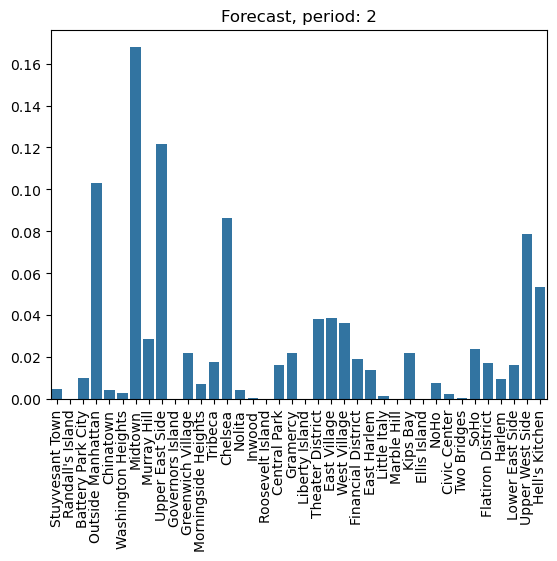

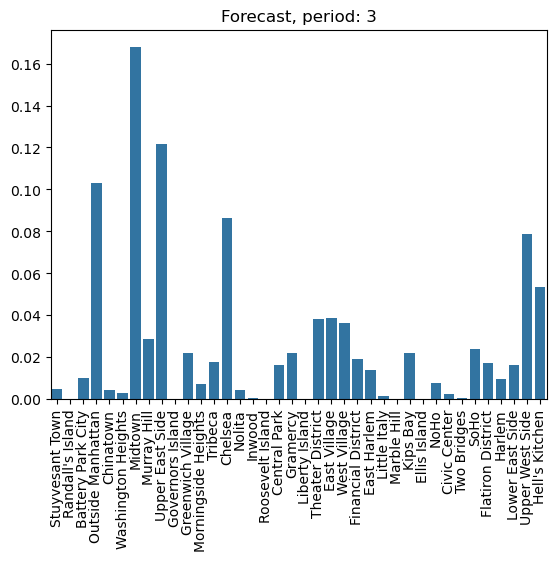

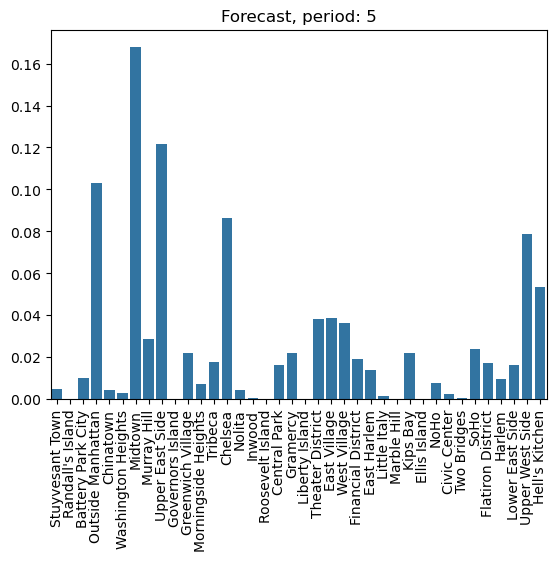

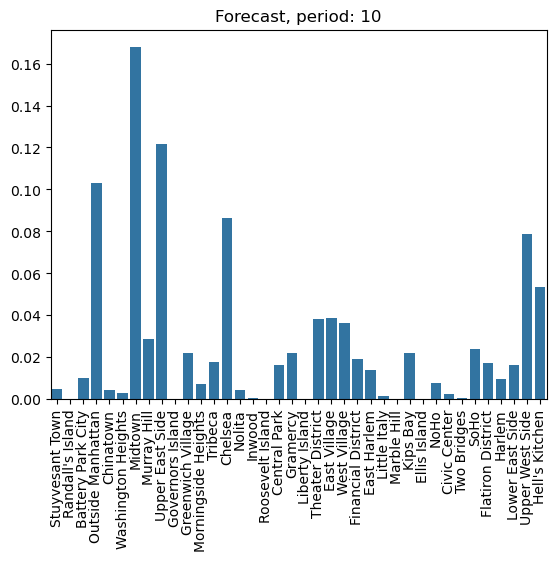

In [16]:
for t in range(n_sim): 
    density = tr_pr @ density
    forecast.append(density) # Append new forecast
    if t in [1, 2, 4, 9]:
        sns.barplot(x=states,y=density).set(title=f'Forecast, period: {str(t+1)}')
        plt.xticks(rotation=90)
        plt.show()

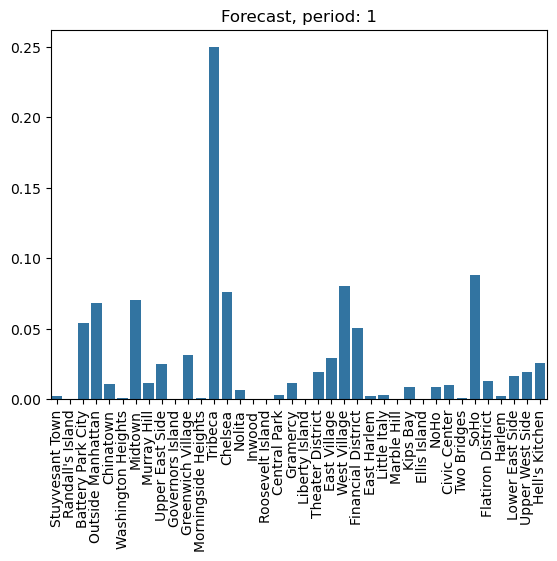

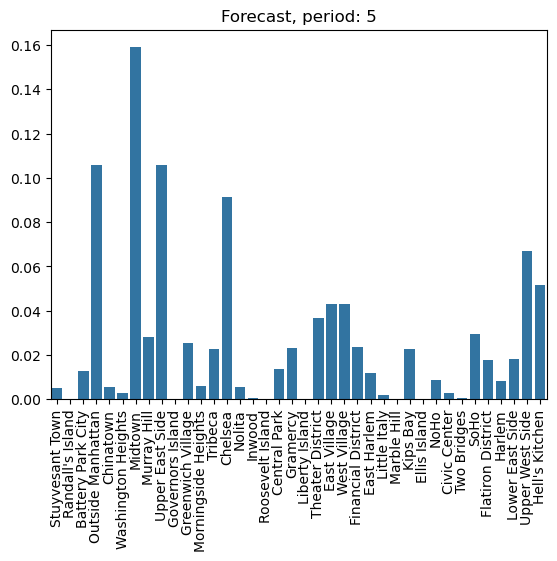

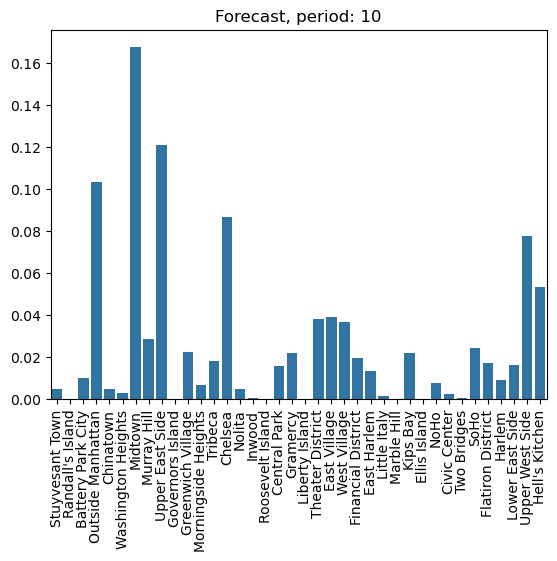

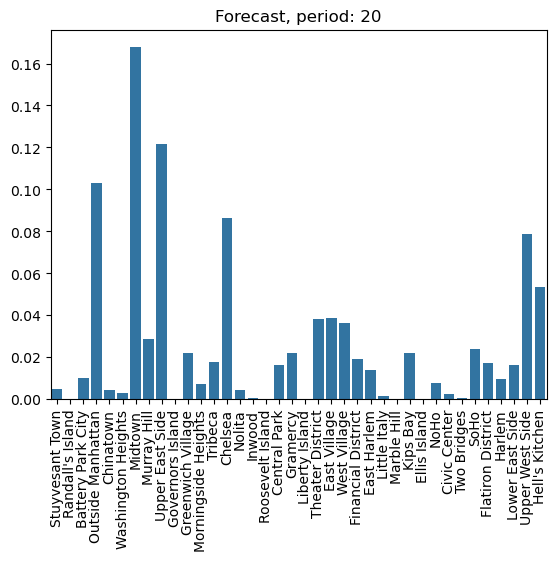

In [129]:
# Starting at any neighborhood, iterate your forecast until it is no longer changing very much. Where do cabs spend most of their time working in Manhattan?
np.random.seed(100)
start = "Tribeca"
state_index = states.index(start) # Get the index of the initial state

##Initial density:
density = np.zeros(len(states))
density[state_index] = 1

n_sim = 20 # Forecast 20 periods 

forecast = [start]
for t in range(n_sim): 
    density = tr_pr @ density
    forecast.append(density) # Append new forecast
    if t in [0, 4, 9, 19]:
        sns.barplot(x=states,y=density).set(title=f'Forecast, period: {str(t+1)}')
        plt.xticks(rotation=90)
        plt.show()

Based on the final forecast at period 20, it looks like a majority of cab rides take place in Midtown, Upper East Side, Chelsea, Upper West Side, and Hell's Kitchen. 